In [1]:
import pandas as pd
from health_analyzer import HealthAnalyzer

df = pd.read_csv("../data/health_study_dataset.csv")
columns = ['age','weight','height','systolic_bp','cholesterol']

# Skapa analys-objekt
analyzer = HealthAnalyzer(df)

In [2]:
# Statistik

stats_table = analyzer.stats(columns)
print(stats_table)

              Medel  Median    Min     Max
age           49.43   50.00   18.0   90.00
weight        73.41   73.20   33.7  114.40
height       171.85  171.35  144.4  200.40
systolic_bp  149.18  149.40  106.8  185.90
cholesterol    4.93    4.97    2.5    7.88


Histogram över systoliskt blodtryck:


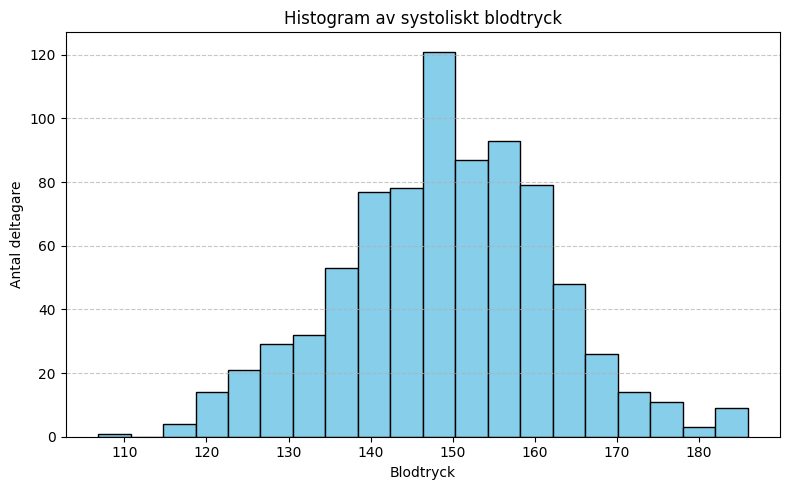

Boxplot över vikt per kön:


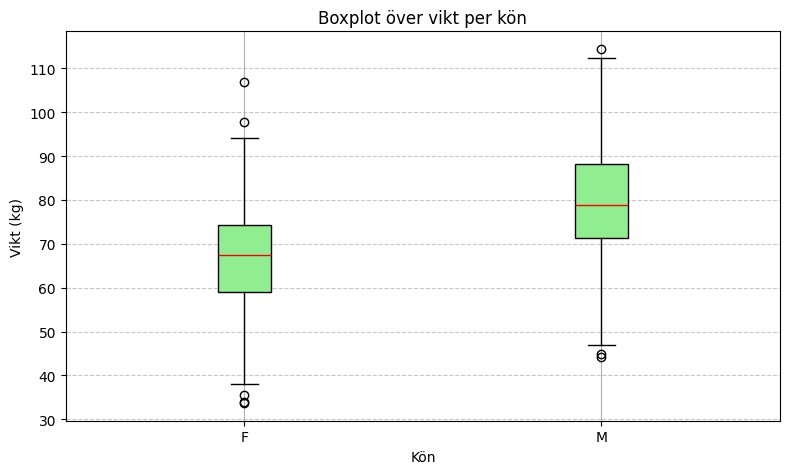

Stapeldiagram över rökare:


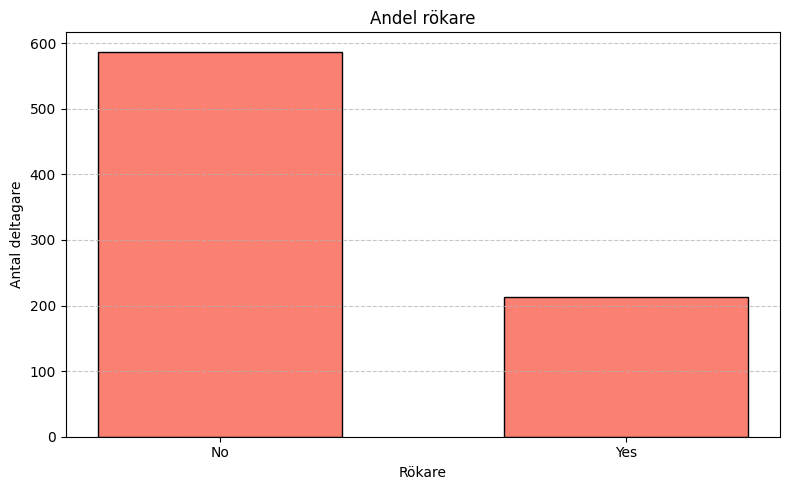

Scatterplot över ålder vs blodtryck


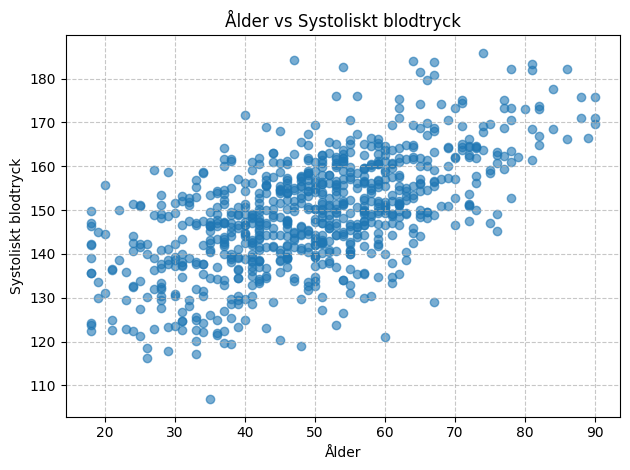

In [3]:
# Grafer

print("Histogram över systoliskt blodtryck:")
analyzer.histogram_bp()

print("Boxplot över vikt per kön:")
analyzer.boxplot_weight()

print("Stapeldiagram över rökare:")
analyzer.bar_smokers()

print("Scatterplot över ålder vs blodtryck")
analyzer.scatter_age_bp() 

In [4]:
# Simulering

simulated_rate = analyzer.simulate_disease(n=1000, seed=42)
actual_rate = df['disease'].mean()

print(f"Verklig andel med sjukdom: {actual_rate:.3f}")
print(f"Simulerad andel med sjukdom (1000 personer): {simulated_rate:.3f}")

Verklig andel med sjukdom: 0.059
Simulerad andel med sjukdom (1000 personer): 0.056


In [5]:
# Konfidensintervall

ci_low, ci_high = analyzer.ci_bp()



95% CI för systoliskt blodtryck: [148.29, 150.07]


In [6]:
# Hypotesprövning: Rökare vs icke-rökare

t_stat, p_value, n_smokers, n_nonsmokers = analyzer.ttest_smokers()

print(f"Antal rökare: {n_smokers}")
print(f"Antal icke-rökare: {n_nonsmokers}")
print(f"T-värde: {t_stat:.4f}")
print(f"P-värde: {p_value:.4f}")

if p_value < 0.05:
    print("Skillnaden mellan grupperna är statistiskt signifikant.")
else:
    print("Ingen statistiskt signifikant skillnad mellan grupperna.")

Antal rökare: 213
Antal icke-rökare: 587
T-värde: 0.4503
P-värde: 0.6527
Ingen statistiskt signifikant skillnad mellan grupperna.


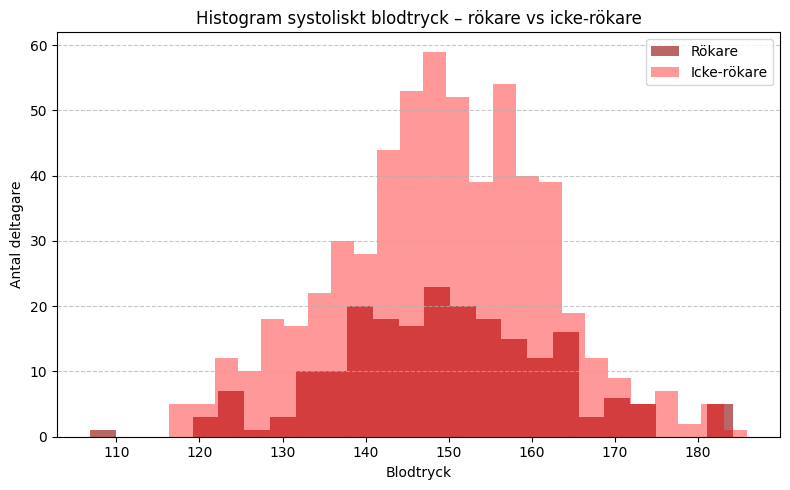

In [7]:
# Dubbelhistogram - Rökare vs icke-rökare

analyzer.histogram_smoker_groups()


In [8]:
# Regression

model = analyzer.regression_age_weight_bp()

print(f"Intercept (startvärde för blodtryck): {model.intercept_:.2f}")
print(f"Koefficienter (lutning): Age -> {model.coef_[0]:.2f}, Weight -> {model.coef_[1]:.2f}")

new_data = pd.DataFrame({'age': [45], 'weight': [70]})
predicted_bp = model.predict(new_data)  
print(f"Predikterat systoliskt blodtryck för 45 år, 70 kg: {predicted_bp[0]:.2f}")

Intercept (startvärde för blodtryck): 109.50
Koefficienter (lutning): Age -> 0.54, Weight -> 0.18
Predikterat systoliskt blodtryck för 45 år, 70 kg: 146.19
